# **项目：酒店预订需求分析 | Hotel Booking Demand Analysis**

## **简介**
本项目基于Kaggle上公开的酒店预订需求数据集，旨在通过数据清洗、探索性分析和可视化，深入理解不同类型酒店的预订行为模式、季节性规律、价格分布特征以及客户取消预订的影响因素，最终为酒店运营策略（如动态定价、营销时机、取消率控制）提供数据驱动的建议。

数据每列含义如下：
- hotel	                            酒店类型	两类：City Hotel（城市酒店）或 Resort Hotel（度假酒店）
- is_canceled	                    是否退订
- lead_time	                        入住时间	从预订日期到实际入住日期的间隔天数
- arrival_date_year	                入住年份	2015, 2016, 2017
- arrival_date_month	            入住月份	字符串，如 "July"
- arrival_date_week_number	        一年中的第几周（1-53）
- arrival_date_day_of_month     	一年中的第几号	1-31
- stays_in_weekend_nights	        周末住宿晚数	周六和周日晚上
- stays_in_week_nights	            工作日住宿晚数	周一至周五晚上
- adults	                        成人人数	
- children	                        儿童人数	缺失值较少（4条），可填充为0
- babies	                        婴儿人数	
- meal	                            订餐情况	如 "BB"（床位含早餐）、"HB"（半食宿）、"FB"（全食宿）、"SC"（无餐）
- country	                        客源国家	ISO 3166-1 alpha-3 三位国家代码，有488条缺失
- market_segment	                市场细分	如 "Direct"（直接）、"Corporate"（公司）、"Online TA"（在线旅行社）等
- distribution_channel	            分销渠道	如 "Direct"、"TA/TO"（旅行社/旅游运营商）等
- is_repeated_guest	                是否回头客	1=是，0=否
- previous_cancellations	        客户在预定前取消的预订次数	
- previous_bookings_not_canceled	客户在预订前未取消的预订次数
- reserved_room_type	            预订的房间类型	用字母编码（A, B, C, D, E, F, G, H, L, P）
- assigned_room_type	            实际分配的房间类型	可能与预订不同（因升级或替代）
- booking_changes	                对预订做出的更改数量	
- deposit_type	                    押金类型	"No Deposit"（无押金）、"Non Refund"（不可退款）、"Refundable"（可退款）
- agent	                            预订代理ID	若为私人预订则为0
- company	                        公司	若为私人预订则为0
- days_in_waiting_list	            确认订单前的审核天数	0表示未进入等待列表
- customer_type	                    客户类型	"Transient"（散客）、"Transient-Party"（团体散客）、"Contract"（合同客户）、"Group"（团体）
- adr	                            平均每日房价	核心数值字段，单位通常为欧元
- required_car_parking_spaces	    客户所需停车位数量	
- total_of_special_requests	        特殊请求总数	如加床、高楼层等
- reservation_status	            最后预订状态	"Check-Out"（已离店）、"Canceled"（已取消）、"No-Show"（未出现）
- reservation_status_date	        状态更新的日期	

## **读取数据**

In [1]:
import numpy as np
import pandas as pd
import ydata_profiling as pp
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["font.serif"] = ["SimHei"]
%matplotlib inline

In [2]:
original_data = pd.read_csv("hotel_bookings.csv")
original_data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## **评估和清理数据**

在这一部分中，我们将对在上一部分建立的original_data DataFrame所包含的数据进行评估和清理。

主要从两个方面进行：结构和内容，即整齐度和干净度。

数据的结构性问题指不符合“每个变量为一列，每个观察值为一行，每种类型的观察单位为一个表格”这三个标准；数据的内容性问题包括存在丢失数据、重复数据、无效数据等

为了区分开经过清理的数据和原始的数据，我们创建新的变量cleaned_data，让它为original_data复制出的副本。我们之后的清理步骤都将被运用在cleaned_data上。

In [3]:
cleaned_data = original_data.copy()

### **数据整齐度**

In [4]:
cleaned_data.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


从头部的10行数据来看，数据符合“每个变量为一列，每个观察值为一行，每种类型的观察单位为一个表格”，因此不存在结构性问题。

### **数据干净度**

In [5]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

从输出结果来看，cleaned_data数据共有119390条观察值，children、country、agent、company变量存在缺失值，将在后续进行评估和清理。

数据类型方面，arrival_date_等可能需合并，并转化为日期格式。
children、agent 均不能是浮点数，需要统一规划为整型数据。

由于arrival_date_month抵达的月份为英文格式，与抵达的年、日格式不符

In [6]:
#修改arrival_date_month的英文月份为中文月份
import calendar
month = []
for i in cleaned_data.arrival_date_month:
    mon = list(calendar.month_name).index(i)
    month.append(mon)
cleaned_data.insert(4,"arrival_month",month)

arrival_date_抵达的年月日，结构单一，建议合并

In [7]:
#增加一列预订到店的年月日arrival_date
cleaned_data[["arrival_date_year","arrival_month","arrival_date_day_of_month"]] = cleaned_data[["arrival_date_year","arrival_month","arrival_date_day_of_month"]].apply(lambda x:x.astype(str))
date = cleaned_data.arrival_date_year.str.cat([cleaned_data.arrival_month,cleaned_data.arrival_date_day_of_month],".")
cleaned_data.insert(3,"arrival_date",date)

将arrival_date转化为日期格式

In [8]:
cleaned_data["arrival_date"] = pd.to_datetime(cleaned_data["arrival_date"])

将原来的年月日信息删除，只采用新建立的arrival_date表示

In [9]:
cleaned_data.drop(["arrival_date_year","arrival_month","arrival_date_month","arrival_date_week_number","arrival_date_day_of_month"],axis = 1,inplace = True)

#### **处理缺失值**

In [10]:
#统计缺失值
cleaned_data.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date                           0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company                           112593
days_in_waiting_list                   0
customer_type                          0
adr             

In [11]:
#统计缺失率
cleaned_data.isnull().sum()/cleaned_data.shape[0]

hotel                             0.000000
is_canceled                       0.000000
lead_time                         0.000000
arrival_date                      0.000000
stays_in_weekend_nights           0.000000
stays_in_week_nights              0.000000
adults                            0.000000
children                          0.000034
babies                            0.000000
meal                              0.000000
country                           0.004087
market_segment                    0.000000
distribution_channel              0.000000
is_repeated_guest                 0.000000
previous_cancellations            0.000000
previous_bookings_not_canceled    0.000000
reserved_room_type                0.000000
assigned_room_type                0.000000
booking_changes                   0.000000
deposit_type                      0.000000
agent                             0.136862
company                           0.943069
days_in_waiting_list              0.000000
customer_ty

数据的缺失值主要存在于children,country,agent,company4个字段，缺失最多的是company

第一，children缺失4个，且为数值型变量，所以用中位数填充

第二，country缺失488个，且为类别型变量，所以使用众数填充

第三，agent缺失16340个，缺失率为13.6%，缺失数量较大，但agent表示预订的旅行社(代理商)，且缺失率小于20%，影响不大建议保留，并用0填充，表示没有旅行社ID

第四，company缺失112593个，缺失率为94.3%>80%,不具备信息价值有效性，所以直接删除

In [12]:
# 处理company字段，直接删除
cleaned_data.drop("company",axis=1,inplace=True)

In [13]:
# 处理children字段，中位数填充
cleaned_data.children.fillna(cleaned_data.children.median(), inplace=True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5812\1633869314.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cleaned_data.children.fillna(cleaned_data.children.median(), inplace=True)


In [14]:
# 处理country字段，众数填充
cleaned_data.country.fillna(cleaned_data.country.mode()[0],inplace=True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5812\60567270.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cleaned_data.country.fillna(cleaned_data.country.mode()[0],inplace=True)


In [15]:
# 处理agent字段，0值填充
cleaned_data.agent.fillna(0, inplace=True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5812\135352596.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cleaned_data.agent.fillna(0, inplace=True)


#### **处理重复数据**

根据数据变量的含义以及内容来看，允许变量重复，我们不需要对此数据检查是否存在重复值。

#### **处理不一致数据**

In [16]:
# children、agent字段不可能为浮点数，需修改数据类型
cleaned_data.children = cleaned_data.children.astype(int)
cleaned_data.agent = cleaned_data.agent.astype(int)

不一致数据可能存在于所有分类变量中，我们要查看是否存在不同值实际指代同一目标的情况。

In [17]:
print(cleaned_data["hotel"].value_counts())
print(cleaned_data["deposit_type"].value_counts())
print(cleaned_data["customer_type"].value_counts())
print(cleaned_data["reservation_status"].value_counts())

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64
reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64


不存在不一致

In [18]:
cleaned_data["meal"].value_counts()

meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

meal里总计有5种餐型，其中Undefined-未被定义 / SC –无餐套餐为一类，需统一替换为SC类

In [19]:
cleaned_data.meal.replace("Undefined", "SC", inplace=True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5812\2609945390.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cleaned_data.meal.replace("Undefined", "SC", inplace=True)


In [20]:
cleaned_data["meal"].value_counts()

meal
BB    92310
HB    14463
SC    11819
FB      798
Name: count, dtype: int64

#### **处理无效或错误数据**

可以通过DataFrame的describe方法，对数值统计信息进行快速了解

In [21]:
cleaned_data.describe()

,is_canceled,lead_time,arrival_date,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016-08-28 16:39:45.727447808,0.927599,2.500302,1.856403,0.103886,0.007949,0.031912,0.087118,0.137097,0.221124,74.828319,2.321149,101.831122,0.062518,0.571363
min,0.000000,0.000000,2015-07-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016-03-13 00:00:00,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016-09-06 00:00:00,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017-03-18 00:00:00,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,152.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017-08-31 00:00:00,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,391.000000,5400.000000,8.000000,5.000000
std,0.482918,106.863097,NaN,0.998613,1.908286,0.579261,0.398555,0.097436,0.175767,0.844336,1.497437,0.652306,107.141953,17.594721,50.535790,0.245291,0.792798


数据集中adults,children,babies字段均为0，即同一订单下，预订入住的人数不能为0，需剔除处理

In [22]:
#删除异常值的行
zero_guests = list(cleaned_data["adults"] + cleaned_data["children"] + cleaned_data["babies"] == 0)
cleaned_data.drop(cleaned_data.index[zero_guests],inplace=True)

adr 酒店平均每日房费有一个大于5000的离群值，会严重影响描述性统计，需删除离群值

<Axes: xlabel='adr'>

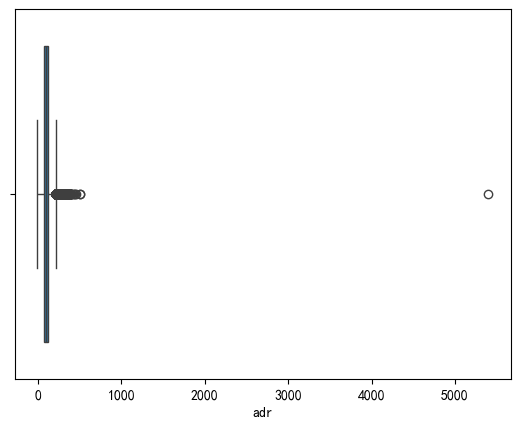

In [23]:
#核实adr变量的离群值情况
sns.boxplot(x=cleaned_data['adr'])

In [24]:
#删除离群值
cleaned_data = cleaned_data[cleaned_data["adr"]<5000]

## **探索数据及可视化**

统计stays_in_weekend_nights+stays_in_week_nights入住的晚数

In [25]:
# 增加一列总住宿晚数stays_nights_total
nums_stays = cleaned_data.stays_in_weekend_nights + cleaned_data.stays_in_week_nights
cleaned_data.insert(4,"stays_nights_total",nums_stays)

将stays_in_weekend_nights、stays_in_week_nights删掉，用stays_nights_total代替

In [26]:
cleaned_data.drop(["stays_in_weekend_nights","stays_in_week_nights"],axis = 1,inplace = True)

统计每单入住人数adults+children+babies

In [27]:
#增加一列住宿人数number_of_people
nums_peoples = cleaned_data.adults + cleaned_data.children + cleaned_data.babies
cleaned_data.insert(5,"number_of_people",nums_peoples)

### **1.指标分析**

#### **（1）预订数量如何**

In [28]:
#统计不同酒店的预订数
book_amount = cleaned_data.groupby("hotel")["is_canceled"].count().reset_index().rename(columns={"is_canceled":"amount"})
book_amount["book_rate"] = round(book_amount.amount/book_amount.amount.sum(),4)
book_amount

,hotel,amount,book_rate
0,City Hotel,79162,0.6641
1,Resort Hotel,40047,0.3359


数据集收录了2015.7.1至2017.8.29期间的所有预定数据，划分为City Hotel(城市酒店)和Resort Hotel(度假酒店)。在不考虑酒店退订的情况下，城市酒店的预订量占比66.41%，是度假酒店预订量的2倍

#### **（2）预订入住率**

In [29]:
#核实总的预订入住率
check_in_rate = str(round(cleaned_data.groupby("is_canceled")["is_canceled"].count()[0]/cleaned_data.shape[0]*100,2))+"%"
canceled_rate = str(round(cleaned_data.groupby("is_canceled")["is_canceled"].count()[1]/cleaned_data.shape[0]*100,2))+"%"
print("该数据的总预订入住率：",check_in_rate)
print("相应的总预订取消率：",canceled_rate)

该数据的总预订入住率： 62.92%
相应的总预订取消率： 37.08%


统计整体的预订入住情况，总的预订入住率还是只停留在62.92%，取消情况会在后续的影响因素分析中进一步挖掘

In [30]:
#度假酒店预订入住情况
rh_is_canceled_count = cleaned_data[cleaned_data["hotel"]=="Resort Hotel"].groupby("is_canceled")["hotel"].count().reset_index().rename(columns={"hotel":"amount"})
rh_cancel_data = pd.DataFrame({"hotel":"度假酒店",
                              "is_canceled":rh_is_canceled_count.is_canceled,
                              "count":rh_is_canceled_count.amount,
                              "is_canceled_rate":rh_is_canceled_count.amount/rh_is_canceled_count.amount.sum()})
rh_cancel_data

,hotel,is_canceled,count,is_canceled_rate
0,度假酒店,0,28927,0.722326
1,度假酒店,1,11120,0.277674


In [31]:
#城市酒店预订入住情况
ch_is_canceled_count = cleaned_data[cleaned_data["hotel"]=="City Hotel"].groupby("is_canceled")["hotel"].count().reset_index().rename(columns={"hotel":"amount"})
ch_cancel_data = pd.DataFrame({"hotel":"城市酒店",
                              "is_canceled":ch_is_canceled_count.is_canceled,
                              "count":ch_is_canceled_count.amount,
                              "is_canceled_rate":ch_is_canceled_count.amount/ch_is_canceled_count.amount.sum()})
ch_cancel_data

,hotel,is_canceled,count,is_canceled_rate
0,城市酒店,0,46084,0.582148
1,城市酒店,1,33078,0.417852


In [32]:
#不同酒店类型预订入住率
is_cancel_data = pd.concat([rh_cancel_data,ch_cancel_data],ignore_index=True)
is_cancel_data

,hotel,is_canceled,count,is_canceled_rate
0,度假酒店,0,28927,0.722326
1,度假酒店,1,11120,0.277674
2,城市酒店,0,46084,0.582148
3,城市酒店,1,33078,0.417852


城市酒店的总预订量大，但同时预订取消率也不低，主要可能是因为城市酒店的主要用户群是商务差旅的用户，往往具有紧急性及未规划性，酒店的预订在未规划及深入了解酒店状态情况下，容易盲目预订、退订，所以城市酒店的退订率高，建议在渠道平台增加“附近优选”功能，通过输入地址，自动筛选推荐附近城市酒店的入住率高、复住率高、评价高等高品质回馈的城市酒店，一方面能为用户提供更高效便捷的推荐服务，另一方面也促使平台渠道优化服务内容。

#### **（3）老客户复定率**

In [33]:
#核实总的复定率
reversal_book_rate = str(round(cleaned_data.groupby("is_repeated_guest")["is_repeated_guest"].count()[1]/cleaned_data.shape[0]*100,2))+"%"
print("该数据的总复定率：",reversal_book_rate)

该数据的总复定率： 3.15%


In [34]:
#不同酒店类型的复住率
data_rb = cleaned_data.groupby(["hotel","is_repeated_guest"])["hotel"].count()
print("城市酒店的复定率：",data_rb["City Hotel",1]/data_rb["City Hotel"].sum())
print("度假酒店的复定率：",data_rb["Resort Hotel",1]/data_rb["Resort Hotel"].sum())

城市酒店的复定率： 0.02497410373664132
度假酒店的复定率： 0.04439783254675756


由上述结论可得，城市酒店和度假酒店的复定率均不高，均是自然客流带来的业务，没有较强的粘性.
— 建议：梳理预订入住流程及服务质量反馈渠道，改善提升服务质量；同时在预订分销渠道(如小程序、小视频、各大软文平台、官网)平台植入相关软文，增加曝光量，收集数据分析数据针对性的提升高价值渠道、高价值客户的投入占比。

### **2.问题分析**

由于后续均是针对不同酒店进行比较，所以划分度假酒店和城市酒店的数据，同时剔除已经取消的订单记录

In [35]:
#返回酒店列的统计值
cleaned_data["hotel"].value_counts()
#划分城市酒店及度假酒店的数据集
rh = cleaned_data[(cleaned_data["hotel"]=="Resort Hotel") & (cleaned_data["is_canceled"]==0)]
ch = cleaned_data[(cleaned_data["hotel"]=="City Hotel") & (cleaned_data["is_canceled"]==0)]

#### **问题1：哪些房型的入住率最高，找出最受欢迎的房型，优化酒店房型分配**

In [36]:
#统计不同酒店、不同房型的入住情况
rh_room = rh.groupby("assigned_room_type")["hotel"].count().reset_index().rename(columns={"hotel":"room_counts"})
ch_room = ch.groupby("assigned_room_type")["hotel"].count().reset_index().rename(columns={"hotel":"room_counts"})

In [37]:
#酒店标识
rh_room["hotel"] = "度假酒店"
ch_room["hotel"] = "城市酒店"
#合并
all_room = pd.concat([ch_room,rh_room],ignore_index=True)
all_room

,assigned_room_type,room_counts,hotel
0,A,30081,城市酒店
1,B,1493,城市酒店
2,C,143,城市酒店
3,D,10698,城市酒店
4,E,1626,城市酒店
5,F,1299,城市酒店
6,G,568,城市酒店
7,K,176,城市酒店
8,A,10996,度假酒店
9,B,150,度假酒店


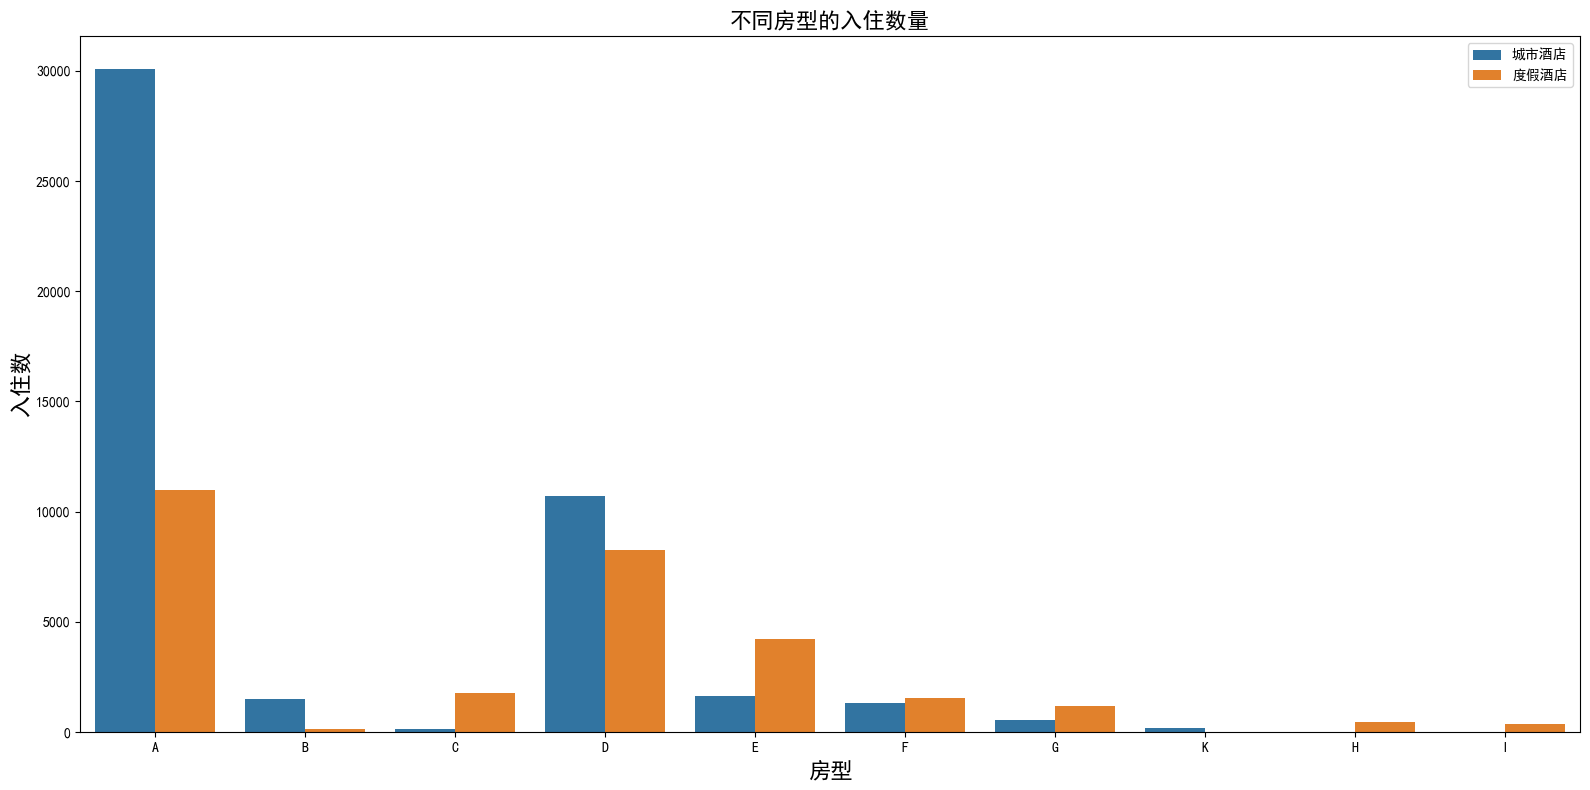

In [38]:
plt.figure(figsize=(16,8))
sns.barplot(x="assigned_room_type",y="room_counts",hue="hotel",data=all_room,hue_order=["城市酒店","度假酒店"])
plt.title("不同房型的入住数量",fontsize=16)
plt.xlabel("房型",fontsize=16)
plt.ylabel("入住数",fontsize=16)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

**结论**：由图可得出无论是城市酒店还是度假酒店房型A、D的入住数明显高于其他房型，可以作为后续主推的房型，并且是主要的房型优化对象，其余B、C、F、G、K、H、L房型均没有太多的预订入住量，可以适当调整房型占比，最大化入住率；另外度假酒店E房型的预订入住数量也不少，可能是酒店的高级套房带观景台或私汤等特殊配套。

**结合时间序列，划分为四季，统计分析四季不同酒店类型的入住量变化情况**

In [39]:
#对月份进行映射，得到对应的季节
rh["month"] =rh["arrival_date"].dt.month
ch["month"] =ch["arrival_date"].dt.month
season_map = {3:'春季',4:'春季',5:'春季',6:'夏季',7:'夏季',8:'夏季',9:'秋季',10:'秋季',11:'秋季',12:'冬季',1:'冬季',2:'冬季'}
rh['season'] = rh['month'].map(season_map)
ch['season'] = ch['month'].map(season_map)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5812\4266707895.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rh["month"] =rh["arrival_date"].dt.month
C:\Users\lenovo\AppData\Local\Temp\ipykernel_5812\4266707895.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ch["month"] =ch["arrival_date"].dt.month
C:\Users\lenovo\AppData\Local\Temp\ipykernel_5812\4266707895.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

In [40]:
#结合时序分析不同酒店、房型在四季的入住情况
rh_room_season = rh.groupby(["reserved_room_type","season"])["hotel"].count().reset_index().rename(columns={"hotel":"room_counts"})
ch_room_season = ch.groupby(["reserved_room_type","season"])["hotel"].count().reset_index().rename(columns={"hotel":"room_counts"})
rh_room_season["hotel"] = "度假酒店"
ch_room_season["hotel"] = "城市酒店"
all_room_season = pd.concat([ch_room_season,rh_room_season],axis=0,ignore_index=True).sort_values("season")
all_room_season

,reserved_room_type,season,room_counts,hotel
0,A,冬季,6005,城市酒店
19,F,冬季,175,城市酒店
27,A,冬季,4148,度假酒店
33,C,冬季,80,度假酒店
15,E,冬季,167,城市酒店
37,D,冬季,850,度假酒店
11,D,冬季,1066,城市酒店
8,C,冬季,2,城市酒店
41,E,冬季,678,度假酒店
49,G,冬季,178,度假酒店


<Figure size 3000x3000 with 0 Axes>

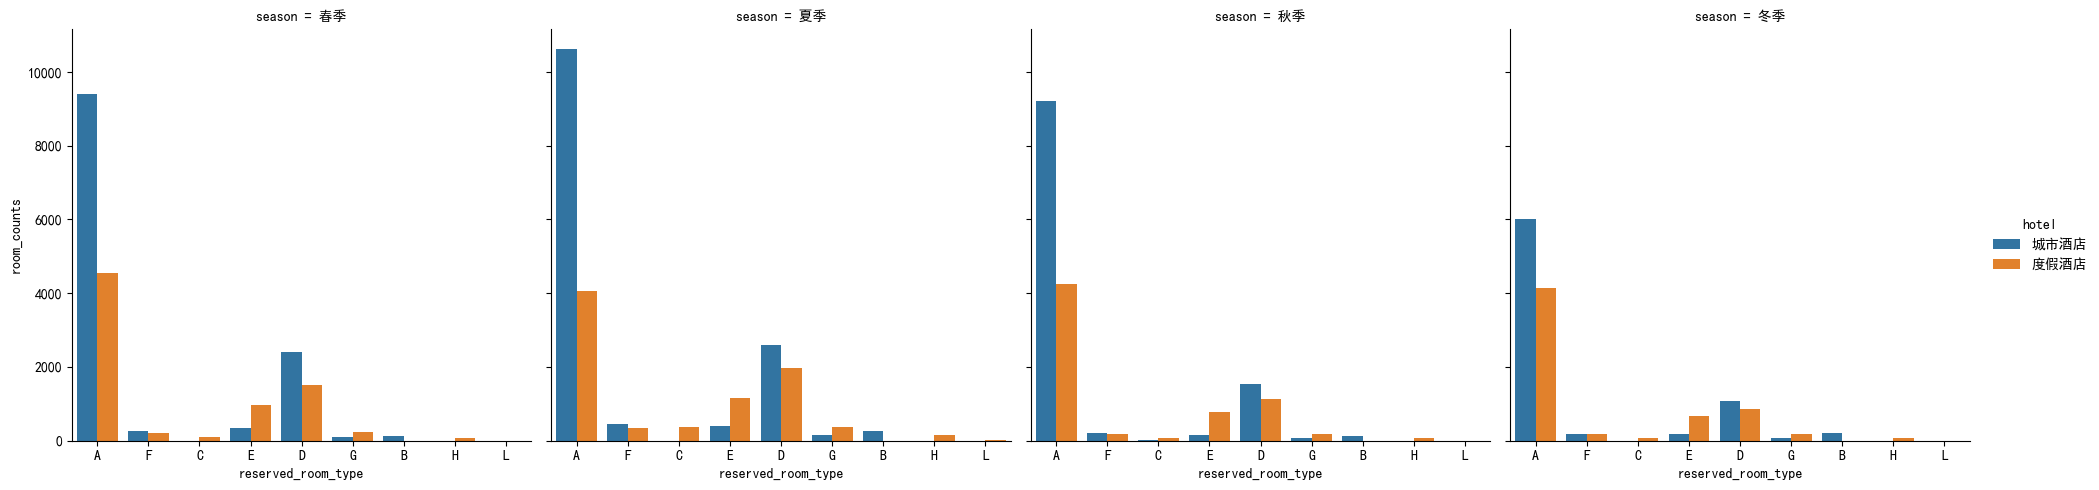

In [41]:
plt.figure(figsize=(30,30))
sns.catplot(x="reserved_room_type",y="room_counts",hue="hotel",col="season",data=all_room_season,kind="bar",col_order=["春季","夏季","秋季","冬季"],hue_order=["城市酒店","度假酒店"])

城市酒店随着季节变化比较明显，春夏的入住量不断攀升，在夏季达到高峰，秋冬逐渐减少，在冬季的客流量处于四季低点；而度假酒店的话，四季基本保持平稳

#### **问题2：客户入住晚数的需求分布情况怎样，哪些的需求量最大，并统计出这些用户偏爱入住的房型**

In [42]:
#统计不同入住晚数的计量
rh_nights_count = rh["stays_nights_total"].value_counts().reset_index().rename(columns={"stays_nights_total":"入住晚数","count":"入住计量"})
ch_nights_count = ch["stays_nights_total"].value_counts().reset_index().rename(columns={"stays_nights_total":"入住晚数","count":"入住计量"})
rh_nights_count["hotel"] = "度假酒店"
ch_nights_count["hotel"] = "城市酒店"
#合并
all_nights_count = pd.concat([rh_nights_count,ch_nights_count],ignore_index=True)
all_nights_count

,入住晚数,入住计量,hotel
0,1,6579,度假酒店
1,2,4488,度假酒店
2,7,4434,度假酒店
3,3,3828,度假酒店
4,4,3321,度假酒店
...,...,...,...
57,21,1,城市酒店
58,24,1,城市酒店
59,18,1,城市酒店
60,23,1,城市酒店


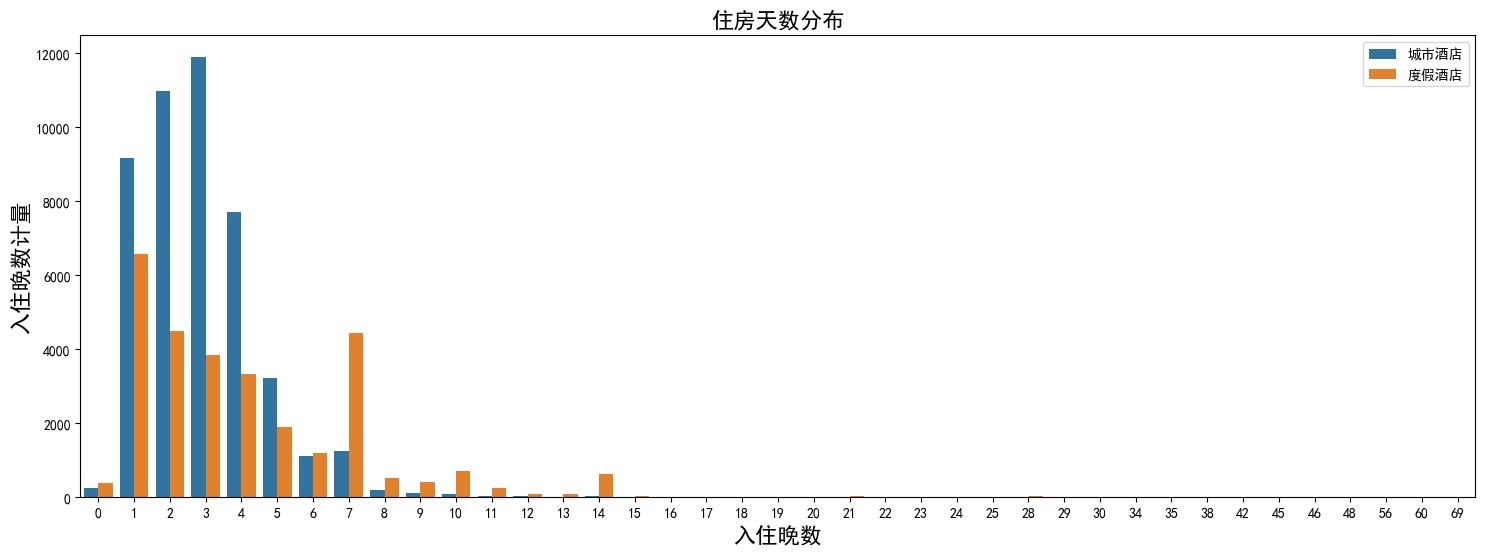

In [43]:
plt.figure(figsize=(18,6))
sns.barplot(x="入住晚数",y="入住计量",hue="hotel",data=all_nights_count,hue_order=["城市酒店","度假酒店"])
plt.title("住房天数分布",fontsize=16)
plt.xlabel("入住晚数",fontsize=16)
plt.ylabel("入住晚数计量",fontsize=16)
plt.legend(loc="upper right")

**结论**：根据入住晚数的统计分析，酒店入住晚数大量分布在1-3晚；同时度假酒店在“7晚预订”上也比较受欢迎，可能是优惠策略或年假一般都是一周的带来的影响

In [44]:
#度假酒店“7晚预订”的客户偏爱的房型
rh[rh["stays_nights_total"]==7].groupby("reserved_room_type")["hotel"].count()

reserved_room_type
A    2111
C     110
D    1248
E     655
F     158
G     113
H      39
Name: hotel, dtype: int64

**结论**：以度假酒店7晚预订来看，这类顾客还是比较偏爱A、D、E的房型，与之前分析整体房型分布没有太大变化

#### **问题3**：用户为何取消预订，哪些因素与此最相关，我们如何判断一个预订订单被取消的可能性

① 从“预订房型与提供房型是否一样”考虑，影响退订的可能性

In [45]:
#预订房型和给定房型的数据
assigned_data = cleaned_data[["is_canceled","reserved_room_type","assigned_room_type"]]

In [46]:
#判断预订房型和给定房型是否一致
assigned_data["equal"] = np.where(assigned_data["reserved_room_type"]==assigned_data["assigned_room_type"],1,0)
#统计一致量
assigned_data["equal"].value_counts()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5812\3932672263.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  assigned_data["equal"] = np.where(assigned_data["reserved_room_type"]==assigned_data["assigned_room_type"],1,0)


equal
1    104413
0     14796
Name: count, dtype: int64

在预订房型和实际给定房型的差别上，仍有14796单无法满足客户入住需求，然后判断下取消订单和房型不一致的关系

In [47]:
#取消订单与房型一致性的关系
assigned_data.groupby(["is_canceled","equal"])["reserved_room_type"].count()

is_canceled  equal
0            0        13995
             1        61016
1            0          801
             1        43397
Name: reserved_room_type, dtype: int64

**结论**：在取消的订单中，预订房型与提供房型不一致的数量有801单，占比取消订单总数的1%，占比如此低，所以不是客户退订的主要因素

②从“提供的餐型”考虑，影响退订的可能性

In [48]:
#餐型数据
meal_data = cleaned_data[["is_canceled","meal"]]
#y表示取消订单，n表示未取消订单，不同餐型的计量
meal_data_y = meal_data[meal_data["is_canceled"]==1].groupby("meal")["meal"].count()
meal_data_n = meal_data[meal_data["is_canceled"]==0].groupby("meal")["meal"].count()
meal_data_n

meal
BB    57730
FB      320
HB     9475
SC     7486
Name: meal, dtype: int64

Text(0.5, 1.0, '预订入住订单的餐型占比')

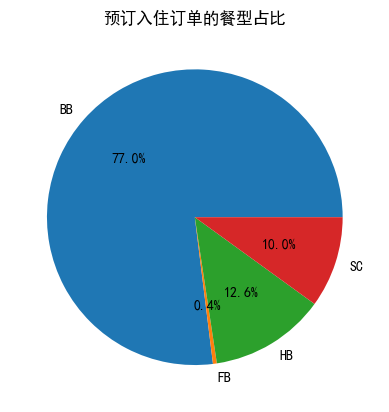

In [49]:
#预订入住的订单中，各餐型占比情况
plt.pie(x=meal_data_n.values,labels=meal_data_n.index,autopct="%.1f%%")
plt.title("预订入住订单的餐型占比")

Text(0.5, 1.0, '退订订单的餐型占比')

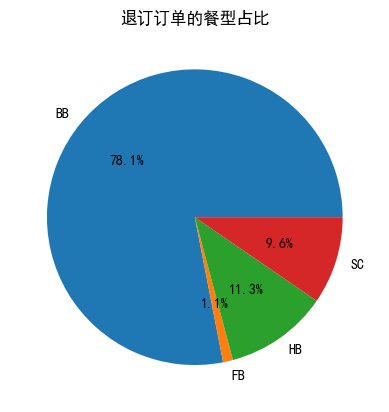

In [50]:
#退订的订单中，各餐型占比情况
plt.pie(x=meal_data_y.values,labels=meal_data_y.index,autopct="%.1f%%")
plt.title("退订订单的餐型占比")

**结论**：对比退订和预订入住的餐型占比，基本一致，没有太大的出入，所以餐型对预订退订的影响不大，排除是因提供的餐食而导致的退订

③从“分销渠道”考虑，影响退订的可能性

In [51]:
#分销渠道数据
channel_data = cleaned_data[["is_canceled","distribution_channel","hotel"]]
#取消订单与分销渠道的关系
cancel_channel_data = channel_data.groupby(["is_canceled","distribution_channel"])["hotel"].count().reset_index().rename(columns={"hotel":"is_cancel_counts"})
cancel_channel_data

,is_canceled,distribution_channel,is_cancel_counts
0,0,Corporate,5184
1,0,Direct,12056
2,0,GDS,156
3,0,TA/TO,57614
4,0,Undefined,1
5,1,Corporate,1467
6,1,Direct,2555
7,1,GDS,37
8,1,TA/TO,40135
9,1,Undefined,4


In [52]:
#不同渠道的总订单量
all_channel_data = cancel_channel_data.groupby("distribution_channel")["is_cancel_counts"].sum()
all_channel_data

distribution_channel
Corporate     6651
Direct       14611
GDS            193
TA/TO        97749
Undefined        5
Name: is_cancel_counts, dtype: int64

In [53]:
# 计算各渠道退订占比
for i in all_channel_data.index:
    cancel_num = cancel_channel_data[(cancel_channel_data["is_canceled"]==1) & (cancel_channel_data["distribution_channel"]==i)]["is_cancel_counts"]
    all_num = all_channel_data[i]
    cancel_rate = cancel_num / all_num * 100
    print("%s渠道的退订占比：%.1f%%" % (i,cancel_rate))

Corporate渠道的退订占比：22.1%
Direct渠道的退订占比：17.5%
GDS渠道的退订占比：19.2%
TA/TO渠道的退订占比：41.1%
Undefined渠道的退订占比：80.0%


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5812\2224938562.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("%s渠道的退订占比：%.1f%%" % (i,cancel_rate))


**结论**：排除掉渠道来源未知的，对比不同渠道的退订占比，发现"TA/TO"渠道的退订占比高，预订入住量及取消量一半一半，可能是渠道分销奖励机制问题，导致该渠道的预订数据有较大的水分，需进一步核实“TA/TO”渠道的分销流程及其中存在的问题

④从“预付定金”考虑，影响退订的可能性

In [54]:
#预付定金数据
deposit_data = cleaned_data[["is_canceled","deposit_type","hotel"]]
#取消订单与预付定金的关系
cancel_deposit_data = deposit_data.groupby(["is_canceled","deposit_type"])["hotel"].count().reset_index().rename(columns={"hotel":"is_cancel_counts"})
cancel_deposit_data

,is_canceled,deposit_type,is_cancel_counts
0,0,No Deposit,74792
1,0,Non Refund,93
2,0,Refundable,126
3,1,No Deposit,29669
4,1,Non Refund,14493
5,1,Refundable,36


**结论**：根据上表，客户更偏爱无定金的预订。但其中仍有大量预付定金的客户选择取消订单，需进一步根据用户画像判断该部分退订客户的属性特征，亦可结合退订的时间分布、位置分布，分析退订的原因

⑤从“提前预定的时间”考虑，影响退订的可能性

Text(0, 0.5, '取消数（%）')

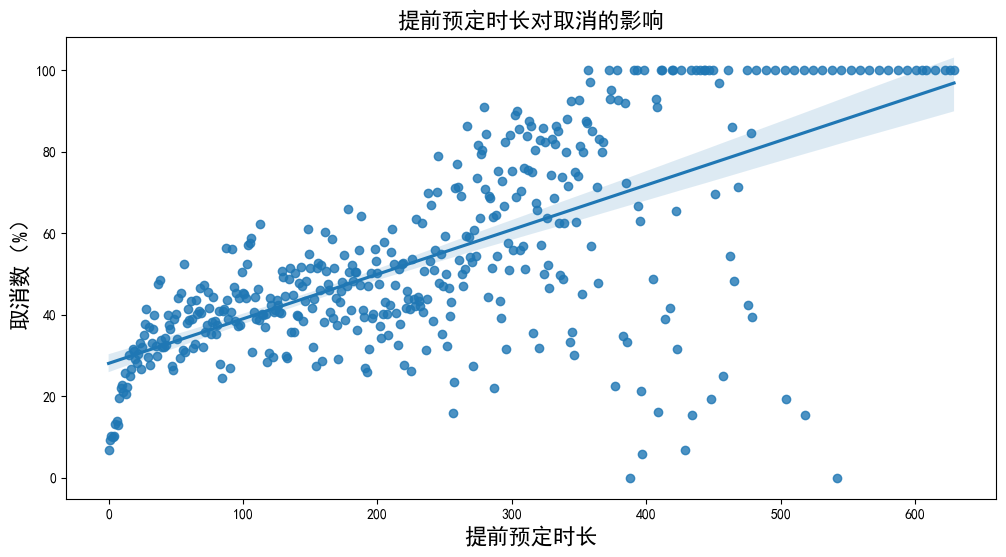

In [55]:
#提前预定时长的数据
lead_data = cleaned_data.groupby("lead_time")["is_canceled"].describe().sort_values(by="mean",ascending=False)
#剔除提前预定时长小于10的数据
lead_data_10 = lead_data[lead_data["count"]>10]
#提前预定时长
x = lead_data_10.index
#对应取消数（按比例归纳值100以内）
y = round(lead_data_10["mean"],4)*100

plt.figure(figsize=(12,6))
sns.regplot(x=x,y=y)
plt.title("提前预定时长对取消的影响",fontsize=16)
plt.xlabel("提前预定时长",fontsize=16)
plt.ylabel("取消数（%）",fontsize=16)

**结论**：根据数据分布情况，整体有随着“提前预定时长”的增加，“取消数”亦增加的规律，两者呈现正相关。所以一般越早预定，也越容易取消。对于这部分影响，建议组织人员对预定日期为“淡季的客户”提前再确认预定入住时间，同时根据优惠策略（提前入住时间越大，优惠越大）释放让利信号，让客户主动提前预定入住的时间

⑥其他影响因素

In [56]:
cancel_corr = cleaned_data.corr(numeric_only=True)["is_canceled"].abs().sort_values(ascending=False)
cancel_corr

is_canceled                       1.000000
lead_time                         0.292885
total_of_special_requests         0.234871
required_car_parking_spaces       0.195700
booking_changes                   0.144847
previous_cancellations            0.110141
is_repeated_guest                 0.083744
adults                            0.058180
previous_bookings_not_canceled    0.057365
days_in_waiting_list              0.054303
adr                               0.047601
agent                             0.046764
number_of_people                  0.044826
babies                            0.032568
stays_nights_total                0.018565
children                          0.004853
Name: is_canceled, dtype: float64

一般来说，相关系数大于0.8时，两者间的相互影响越大
根据上表，影响取消数的主要属性是：
- lead_time:提前预定天数
- total_of_special_requests:客户提出的特殊要求的数量
- required_car_parking_spaces:客户要求的停车位数
- booking_changes:对预订所作的更改/修改的数目
- previous_cancellations:客户在当前预订前取消的先前预订数